In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend ,resample
import os

In [2]:
data_path = '/kaggle/input/datasets/roaahussein/eog-classes/3-class'

In [3]:
def plot_eog_channels(data_dict, step_title):
    """
    Function to plot Horizontal and Vertical channels for all classes.
    data_dict: Dictionary containing {label: [h_signal, v_signal]}
    step_title: String title for the entire plot
    """
    fig, axes = plt.subplots(len(data_dict), 2, figsize=(15, 20))
    fig.suptitle(step_title, fontsize=16)
    
    for i, (label, signals) in enumerate(data_dict.items()):
        h_signal, v_signal = signals[0], signals[1]
        
        # Plot Horizontal (H)
        axes[i, 0].plot(h_signal, color='blue')
        axes[i, 0].set_title(f'{label} - Horizontal (H)')
        axes[i, 0].grid(True)
        
        # Plot Vertical (V)
        axes[i, 1].plot(v_signal, color='red')
        axes[i, 1].set_title(f'{label} - Vertical (V)')
        axes[i, 1].grid(True)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot a signal from each class 

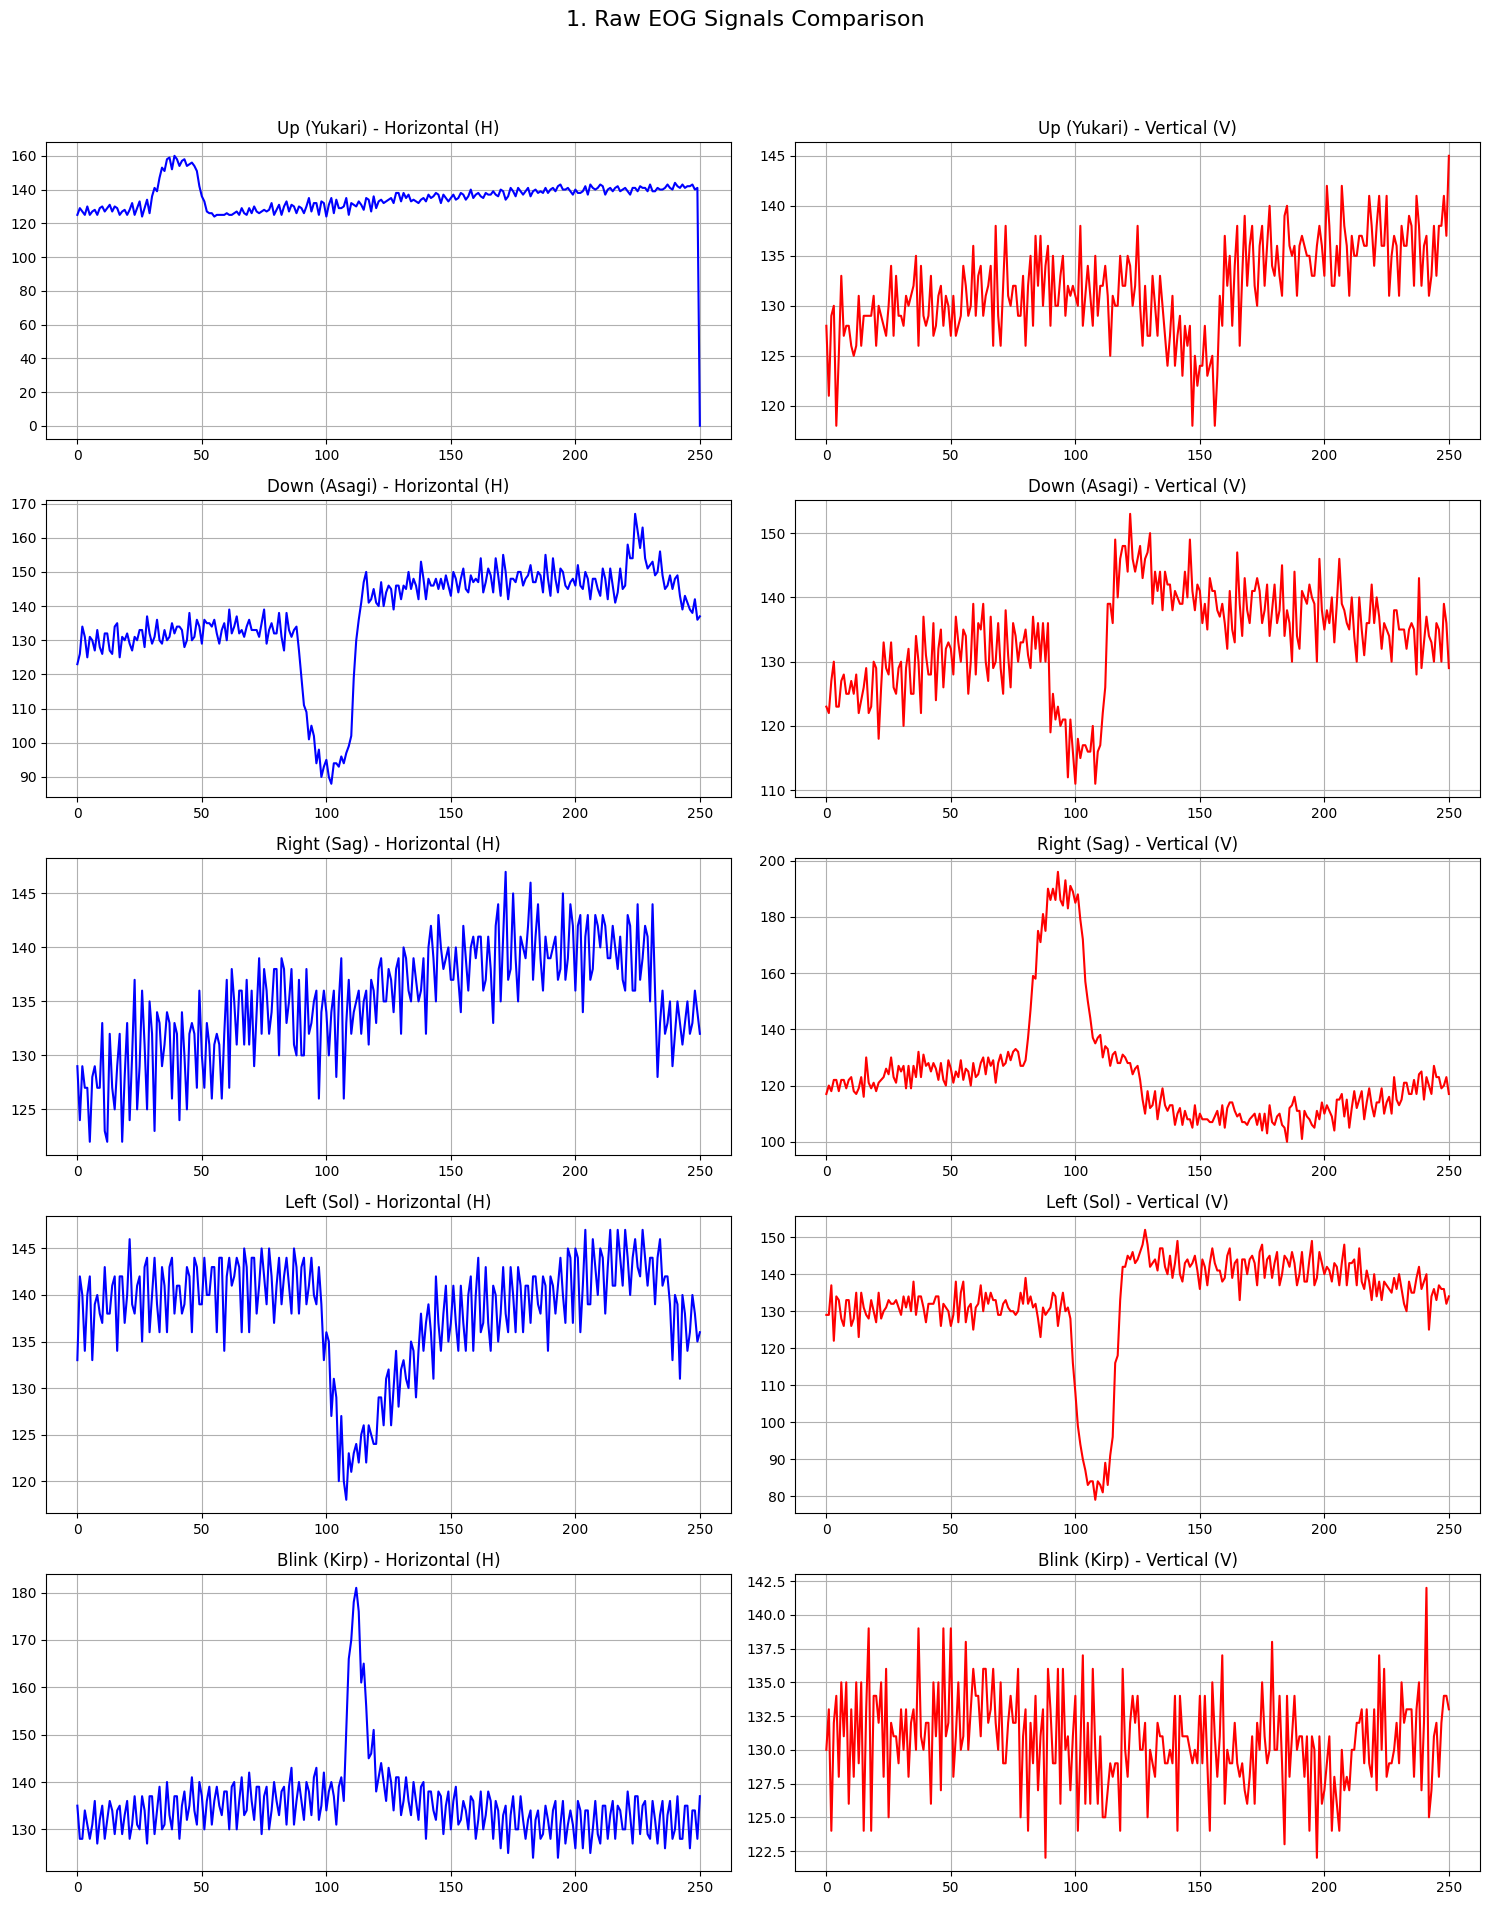

In [4]:
# Initial sample files mapping
samples_map = {
    'Up (Yukari)': ('yukari10h.txt', 'yukari10v.txt'),
    'Down (Asagi)': ('asagi10h.txt', 'asagi10v.txt'),
    'Right (Sag)': ('sag10h.txt', 'sag10v.txt'),
    'Left (Sol)': ('sol10h.txt', 'sol10v.txt'),
    'Blink (Kirp)': ('kirp10h.txt', 'kirp10v.txt')
}

# Load Raw Data into a Dictionary
current_data = {}
for label, files in samples_map.items():
    h_sig = np.loadtxt(os.path.join(data_path, files[0]))
    v_sig = np.loadtxt(os.path.join(data_path, files[1]))
    current_data[label] = [h_sig, v_sig]

# Plot Raw
plot_eog_channels(current_data, "1. Raw EOG Signals Comparison")

In [5]:
# 1. Baseline Correction (DC Removal)
def remove_dc(signal):
    # Uses linear detrending to remove drift and center the signal around zero
    return detrend(signal)

# 2. Digital Bandpass Filter
def apply_bandpass(signal, fs=176, low=0.5, high=20.0):
    # Filters out high-frequency muscle noise and low-frequency drift
    nyq = 0.5 * fs
    low_cut = low / nyq
    high_cut = high / nyq
    b, a = butter(4, [low_cut, high_cut], btype='band')
    return filtfilt(b, a, signal)

# 4. Amplitude Normalization
def apply_normalization(signal):
    # Z-score normalization to ensure fair feature weight during classification[cite: 1]
    return (signal - np.mean(signal)) / np.std(signal)

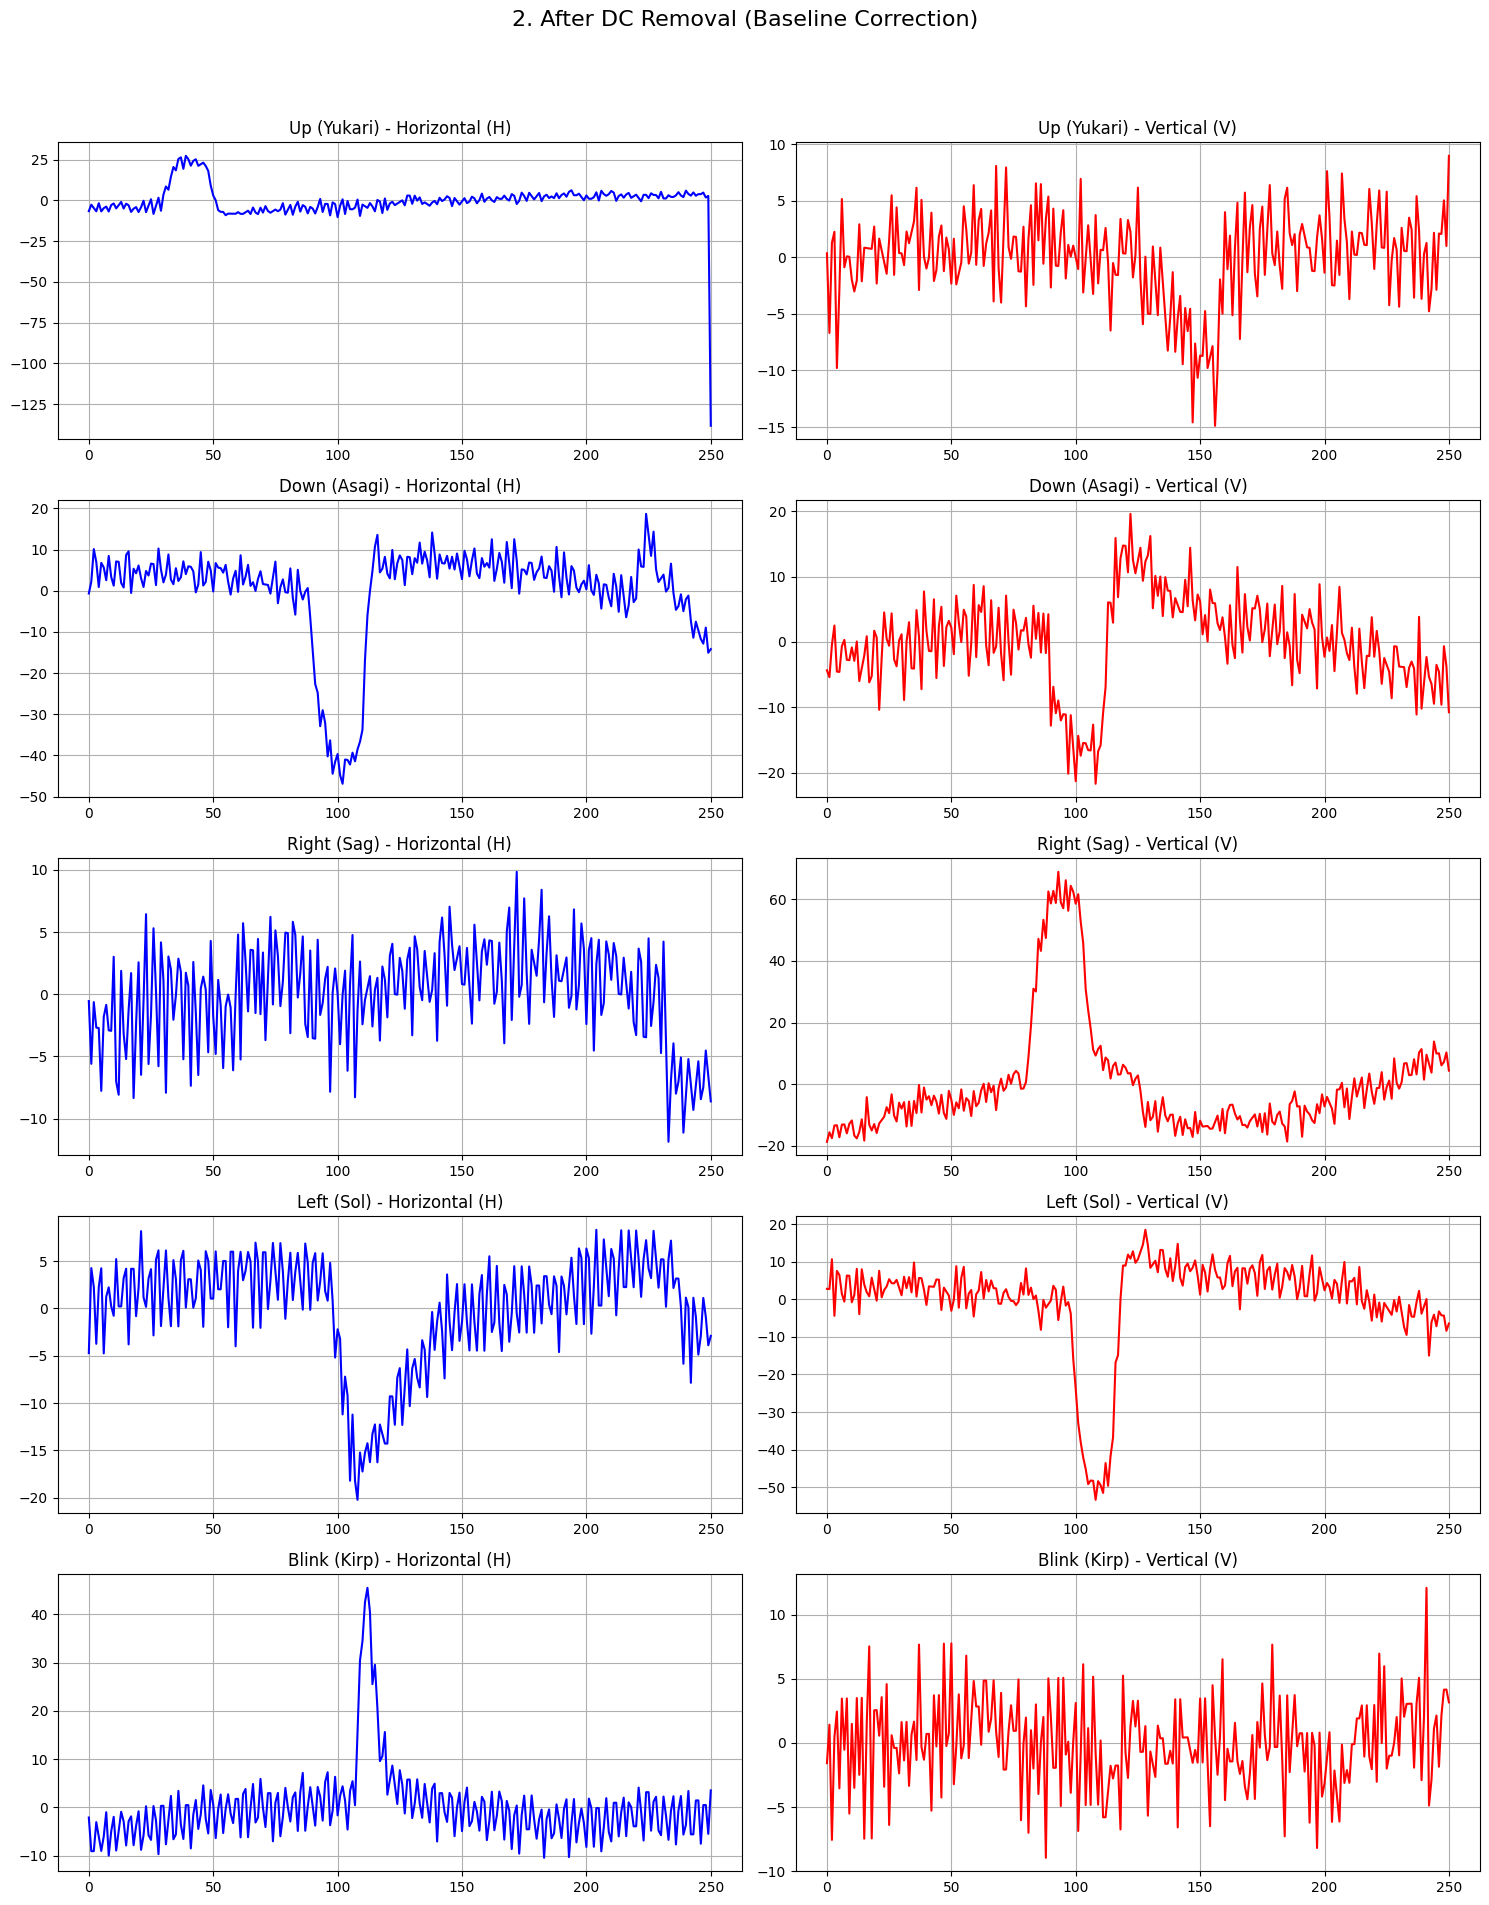

In [6]:
# Apply DC Removal
for label in current_data:
    current_data[label] = [remove_dc(sig) for sig in current_data[label]]

# Plot after DC Removal
plot_eog_channels(current_data, "2. After DC Removal (Baseline Correction)")

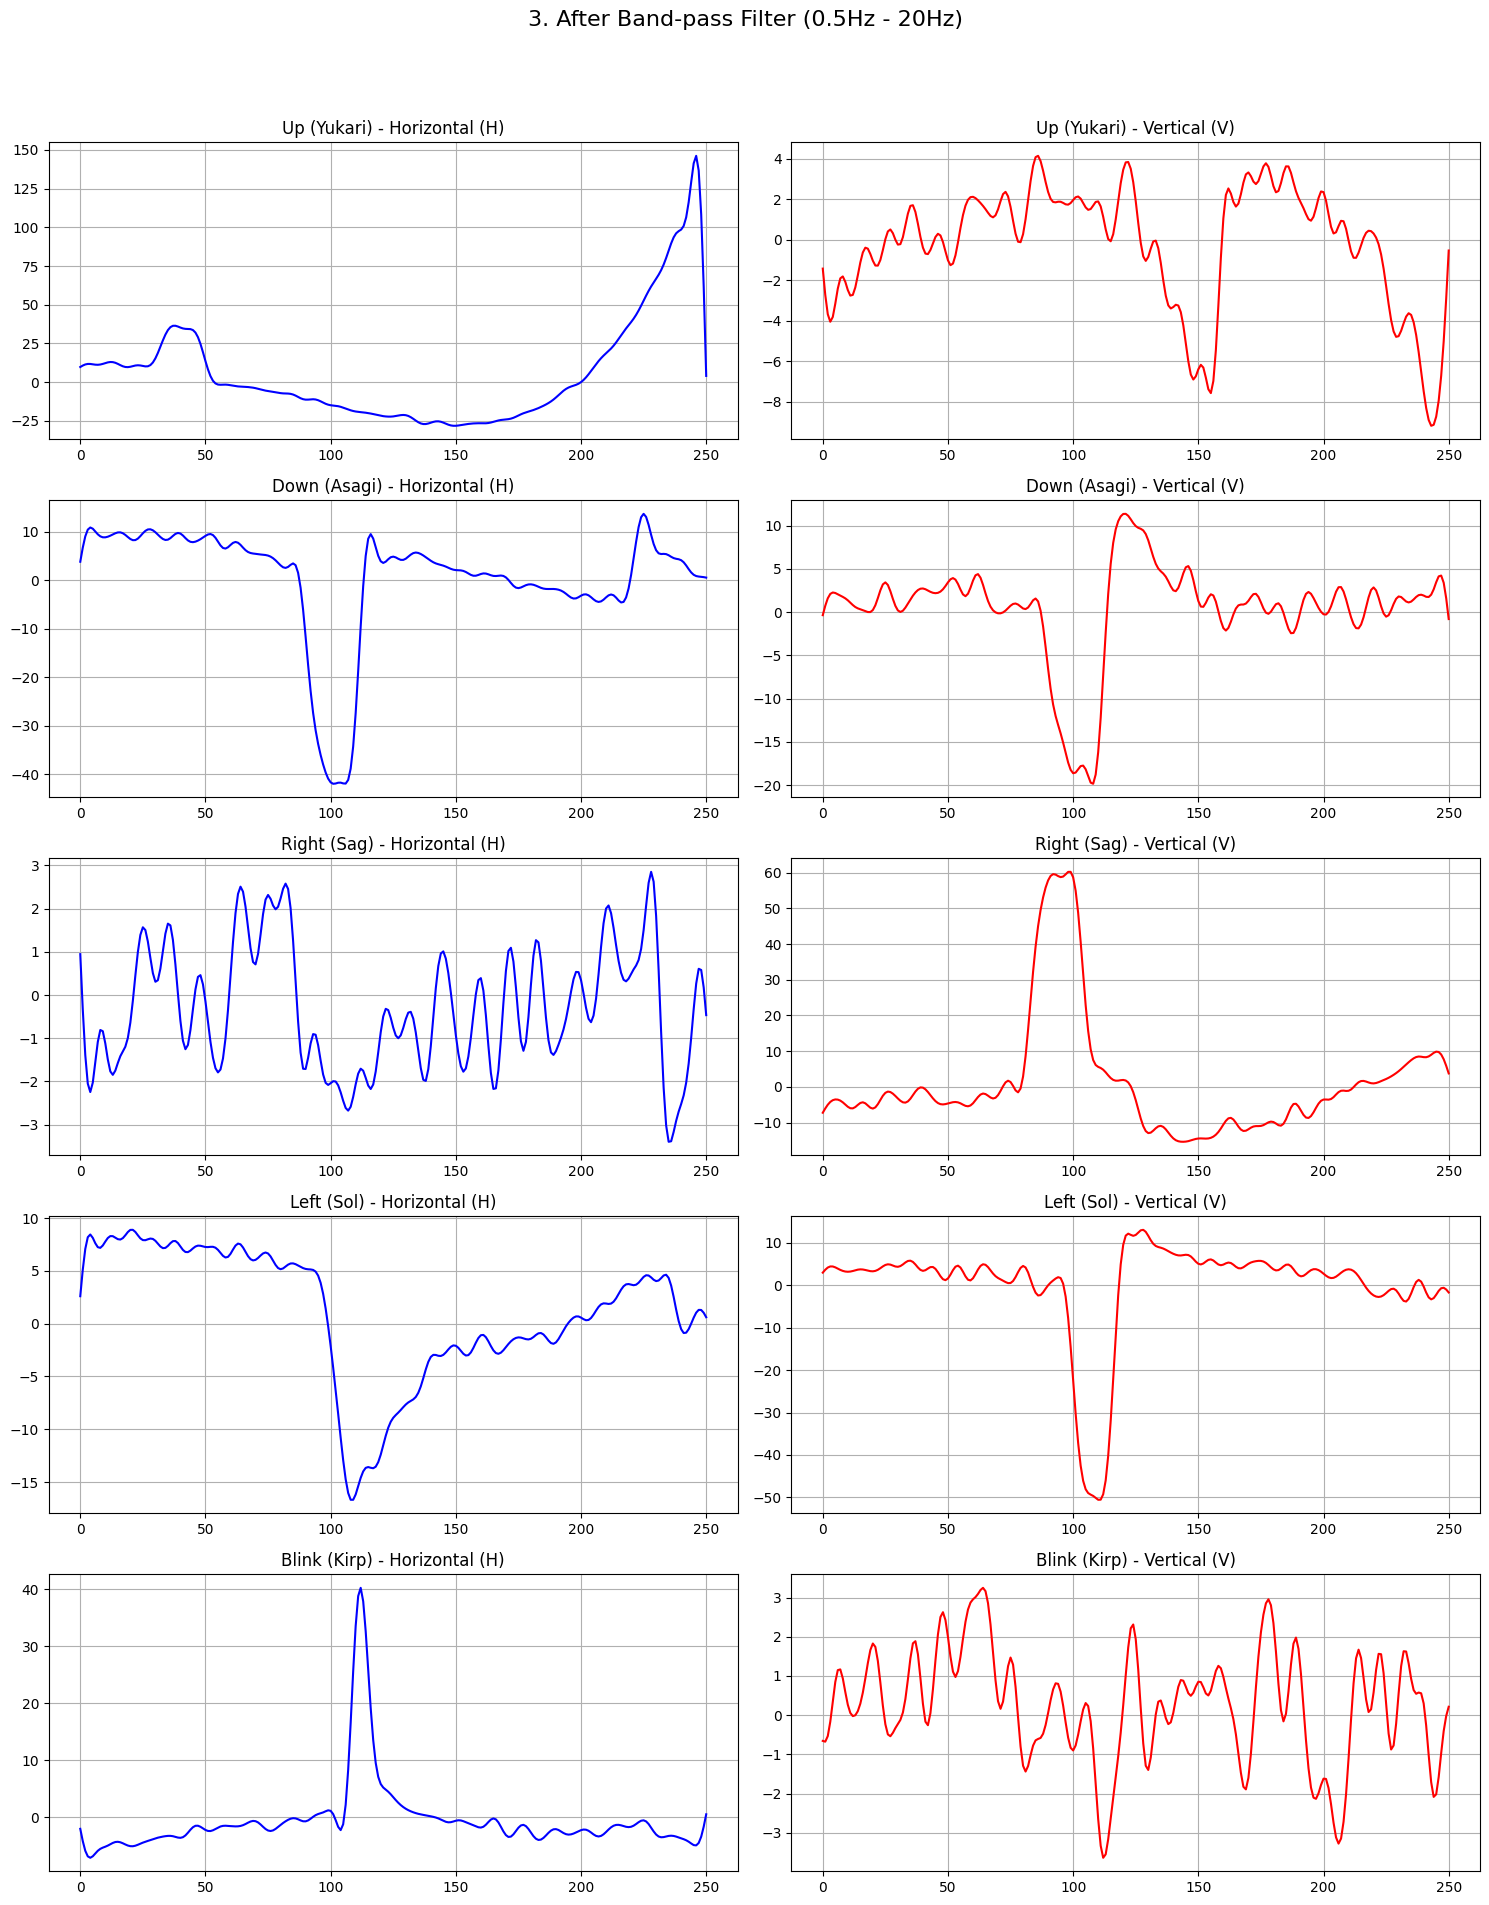

In [7]:
# Apply Filter
for label in current_data:
    current_data[label] = [apply_bandpass(sig) for sig in current_data[label]]

# Plot after Filtering
plot_eog_channels(current_data, "3. After Band-pass Filter (0.5Hz - 20Hz)")

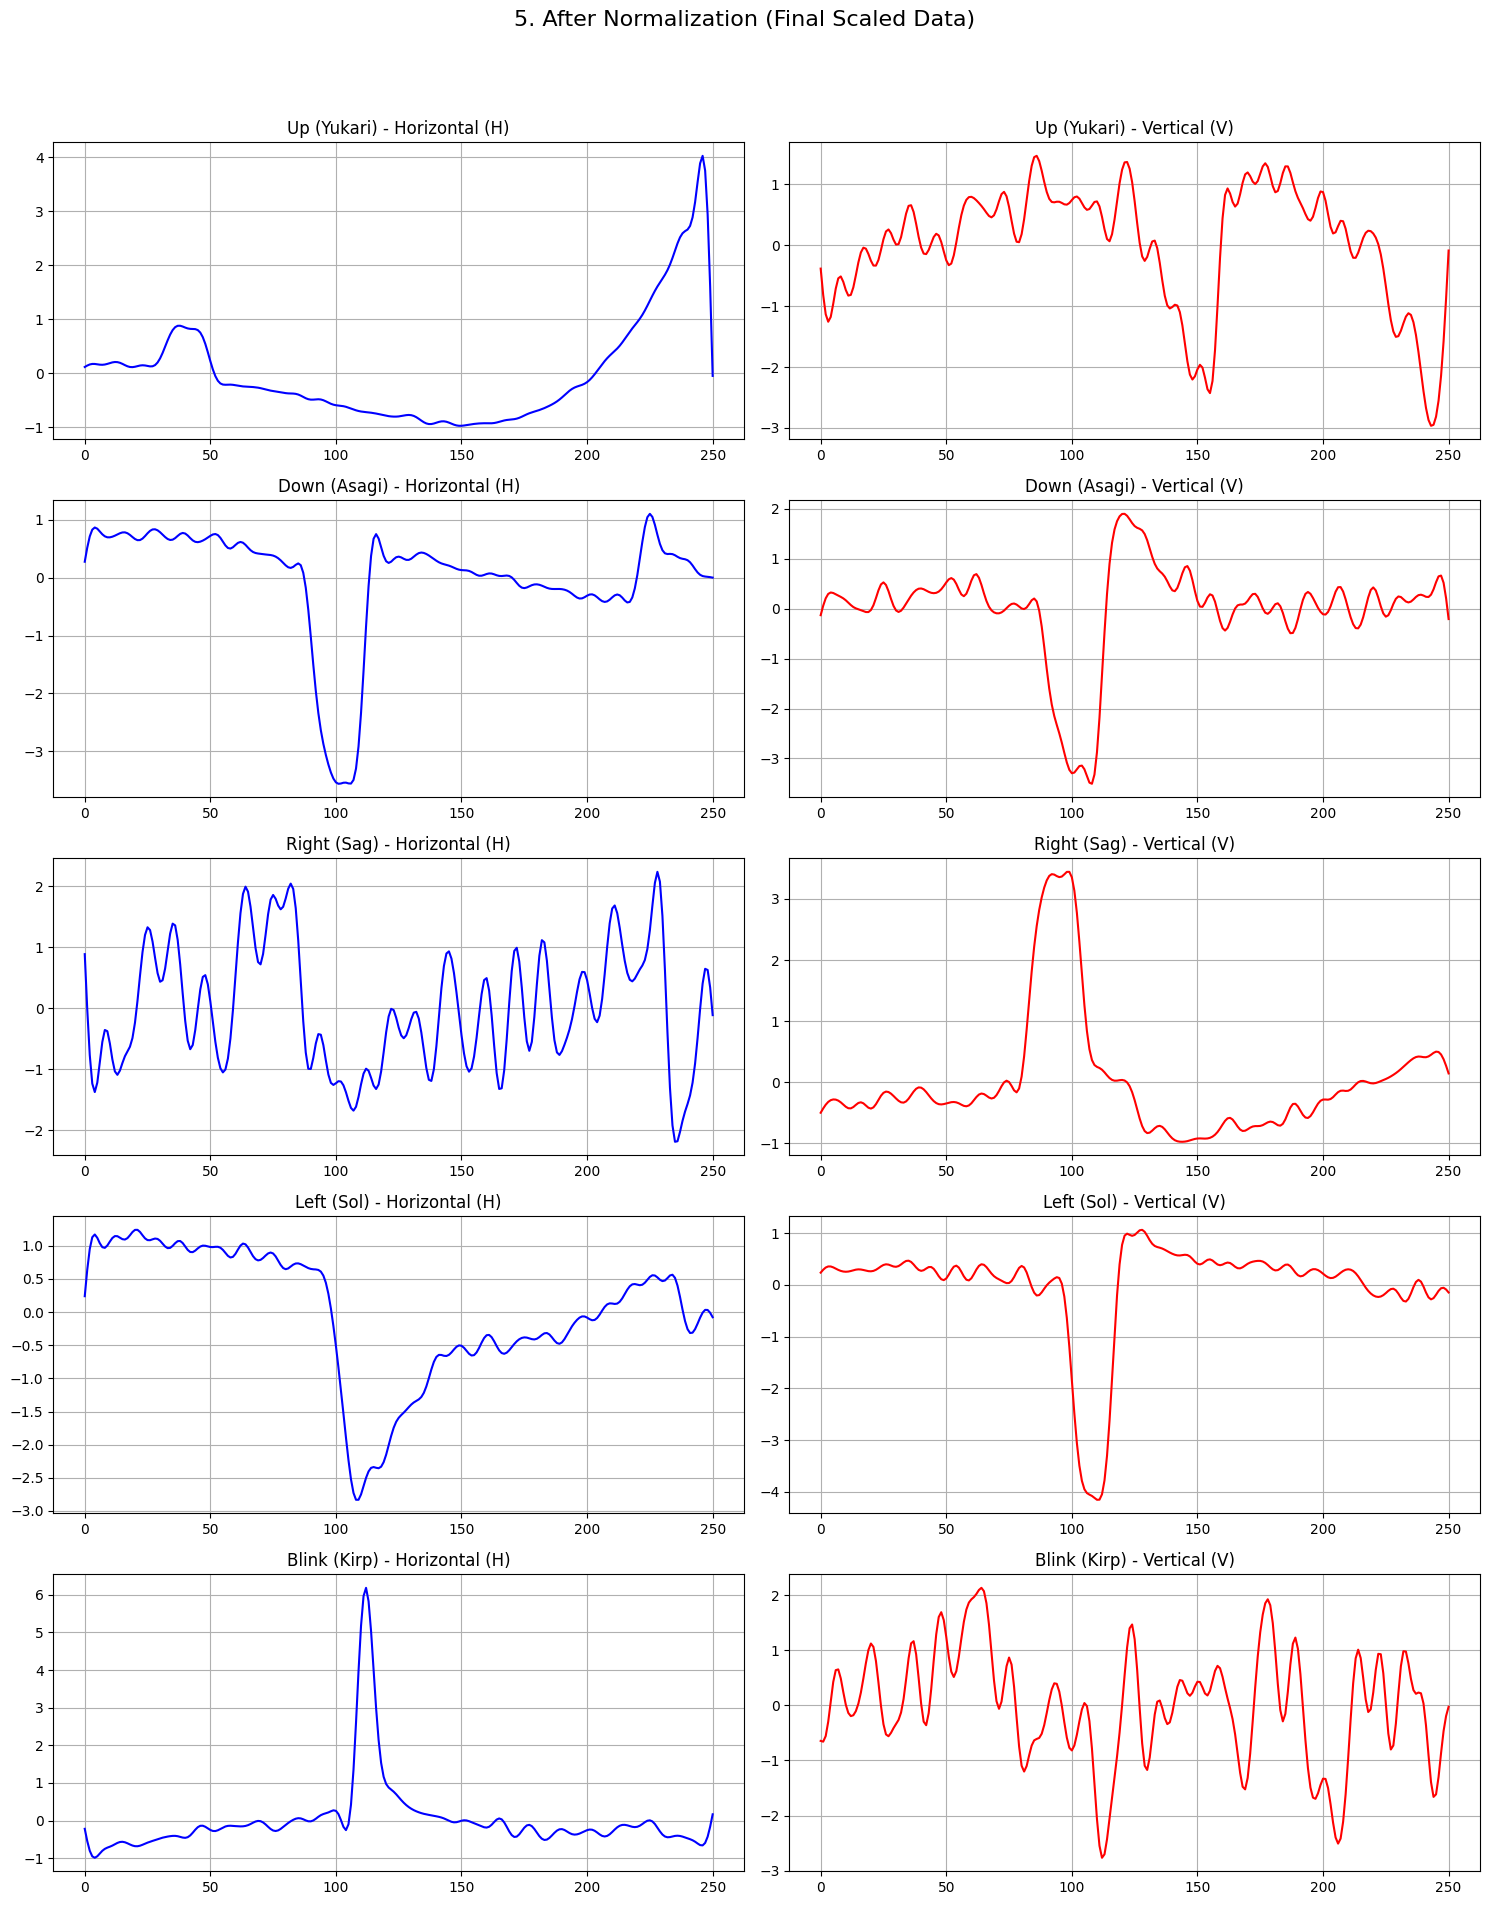

In [8]:
# Apply Normalization
for label in current_data:
    current_data[label] = [apply_normalization(sig) for sig in current_data[label]]

plot_eog_channels(current_data, "5. After Normalization (Final Scaled Data)")

# Final Dataset Preparation

In [9]:
# Class label mapping
CLASS_MAP = {
    'yukari': 0,  # Up
    'asagi':  1,  # Down
    'sag':    2,  # Right
    'sol':    3,  # Left
    'kirp':   4,  # Blink
}

def preprocess_signal(signal, fs=176):
    """Full preprocessing pipeline: DC removal -> Bandpass -> Normalization"""
    signal = detrend(signal)
    signal = apply_bandpass(signal, fs=fs)
    signal = apply_normalization(signal)
    return signal

def load_all_data(data_path, class_map):
    """
    Loads all recordings for all classes.
    Returns:
        signals_H: np.array of shape (n_trials, 251) -- preprocessed H channel per trial
        signals_V: np.array of shape (n_trials, 251) -- preprocessed V channel per trial
        y:         np.array of shape (n_trials,)     -- class label per trial
    """
    signals_H, signals_V, y = [], [], []

    for cls_name, cls_label in class_map.items():
        idx = 1
        while True:
            h_file = os.path.join(data_path, f'{cls_name}{idx}h.txt')
            v_file = os.path.join(data_path, f'{cls_name}{idx}v.txt')

            if not os.path.exists(h_file) or not os.path.exists(v_file):
                break  # No more recordings for this class

            h_proc = preprocess_signal(np.loadtxt(h_file))
            v_proc = preprocess_signal(np.loadtxt(v_file))

            signals_H.append(h_proc)
            signals_V.append(v_proc)
            y.append(cls_label)

            idx += 1

        print(f'{cls_name}: loaded {idx-1} recordings')

    return np.array(signals_H), np.array(signals_V), np.array(y)


signals_H, signals_V, y = load_all_data(data_path, CLASS_MAP)

print(f'\nFinal dataset shape:')
print(f'  signals_H: {signals_H.shape}  --> {signals_H.shape[0]} trials x 251 H timepoints')
print(f'  signals_V: {signals_V.shape}  --> {signals_V.shape[0]} trials x 251 V timepoints')
print(f'  y:         {y.shape}          --> labels (0=Up, 1=Down, 2=Right, 3=Left, 4=Blink)')
print(f'\nSamples per class: {dict(zip(CLASS_MAP.keys(), [np.sum(y==v) for v in CLASS_MAP.values()]))}')

# Save for Feature Extraction notebook
np.save('signals_H.npy', signals_H)
np.save('signals_V.npy', signals_V)
np.save('y_labels.npy',  y)
print('\nSaved: signals_H.npy, signals_V.npy, y_labels.npy')

yukari: loaded 20 recordings
asagi: loaded 20 recordings
sag: loaded 20 recordings
sol: loaded 20 recordings
kirp: loaded 20 recordings

Final dataset shape:
  signals_H: (100, 251)  --> 100 trials x 251 H timepoints
  signals_V: (100, 251)  --> 100 trials x 251 V timepoints
  y:         (100,)          --> labels (0=Up, 1=Down, 2=Right, 3=Left, 4=Blink)

Samples per class: {'yukari': np.int64(20), 'asagi': np.int64(20), 'sag': np.int64(20), 'sol': np.int64(20), 'kirp': np.int64(20)}

Saved: signals_H.npy, signals_V.npy, y_labels.npy


In [10]:
label_map = {0: 'Up', 1: 'Down', 2: 'Right', 3: 'Left', 4: 'Blink'}

df_h = pd.DataFrame(signals_H, columns=[f'H_{i}' for i in range(251)])
df_v = pd.DataFrame(signals_V, columns=[f'V_{i}' for i in range(251)])

df = pd.concat([df_h, df_v], axis=1)
df['label'] = [label_map[i] for i in y]
df['class'] = y

df.to_csv('eog_preprocessed.csv', index=False)
print(f'Saved: eog_preprocessed.csv  →  {df.shape[0]} trials x {df.shape[1]} columns')

print(df.head())
print(f'\nShape: {df.shape}')

Saved: eog_preprocessed.csv  →  100 trials x 504 columns
        H_0       H_1       H_2       H_3       H_4       H_5       H_6  \
0 -0.143854 -0.237264 -0.300789 -0.317643 -0.289120 -0.230410 -0.162156   
1 -0.111062 -0.212800 -0.293725 -0.343080 -0.363230 -0.364717 -0.358093   
2 -0.359761 -0.357665 -0.357566 -0.358415 -0.356145 -0.346826 -0.329919   
3 -0.331182 -0.463134 -0.564811 -0.619447 -0.629230 -0.610418 -0.582692   
4 -0.008751 -0.074211 -0.137216 -0.194848 -0.243137 -0.276887 -0.291039   

        H_7       H_8       H_9  ...     V_243     V_244     V_245     V_246  \
0 -0.103355 -0.067864 -0.063420  ...  1.312444  1.262697  1.134281  0.949370   
1 -0.348345 -0.334798 -0.315336  ... -0.629955 -0.397543 -0.119318  0.117463   
2 -0.308741 -0.287570 -0.267452  ... -1.414867 -1.738266 -2.079137 -2.286814   
3 -0.559814 -0.546289 -0.540113  ...  0.254262  0.349665  0.419060  0.403719   
4 -0.283224 -0.255978 -0.217116  ...  0.963974  1.366128  1.660516  1.774398   

      V_247